# Uber A/B Test Analysis
Analysis of cancellation rate and match rate across experimental groups.

In [16]:
# ==============================================================================
# 1. SETUP AND DATA LOADING
# ==============================================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

try:
    uber = (
        pd.read_csv('../../data/uber.csv')
        .assign(
            period_start=lambda df: pd.to_datetime(df['period_start'], format='%d/%m/%y %H:%M')
        )
    )
    print("Data loaded successfully.")
    print(f"Shape: {uber.shape}")
    uber.head()
except FileNotFoundError:
    print("Error: 'data/uber.csv' not found. Place the CSV in a 'data/' subfolder.")
    uber = pd.DataFrame()

Data loaded successfully.
Shape: (126, 4)


In [6]:
uber.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   period_start       126 non-null    datetime64[us]
 1   cancellation_rate  126 non-null    float64       
 2   match_rate         126 non-null    float64       
 3   group              126 non-null    str           
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 4.1 KB


## 2. Cancellation Rate Over Time

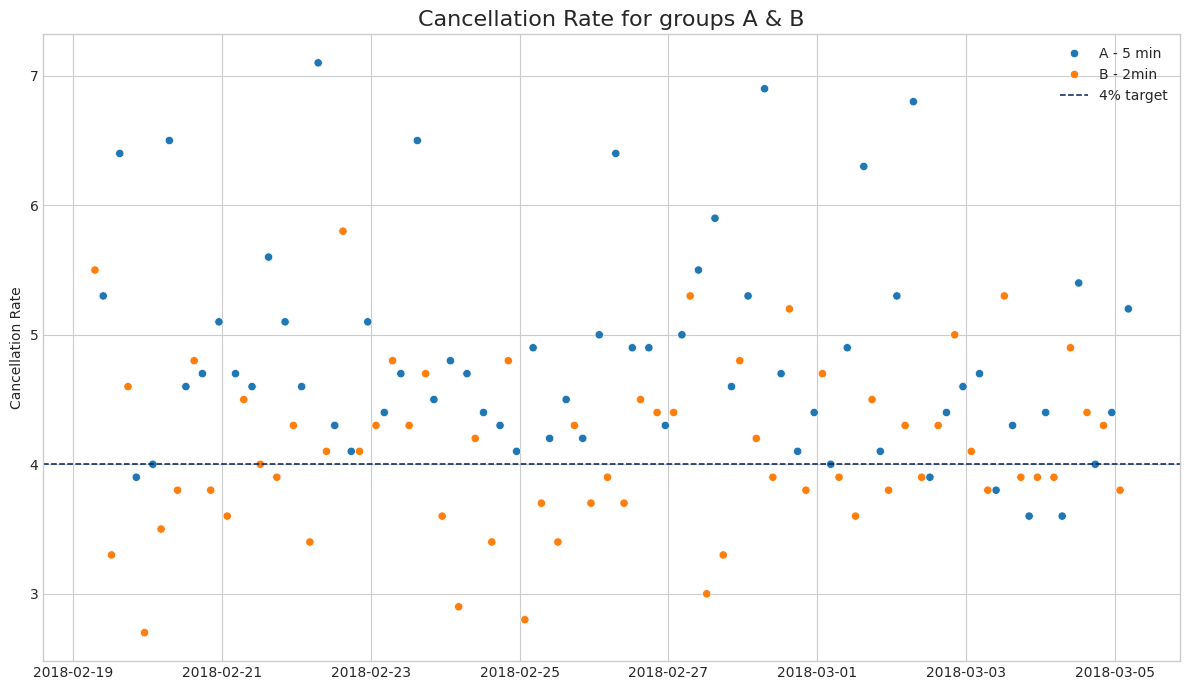

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=uber,
    x='period_start',
    y='cancellation_rate',
    hue='group',
    ax=ax
)

ax.axhline(y=4, color="#001e62", linewidth=1.1, linestyle="--", label="4% target")

ax.set_title("Cancellation Rate for groups A & B", fontsize=16)
ax.set(xlabel=None, ylabel="Cancellation Rate")
ax.legend()

plt.tight_layout()
plt.show()

## 3. Cancellation Rate by Group (with 95% CI)

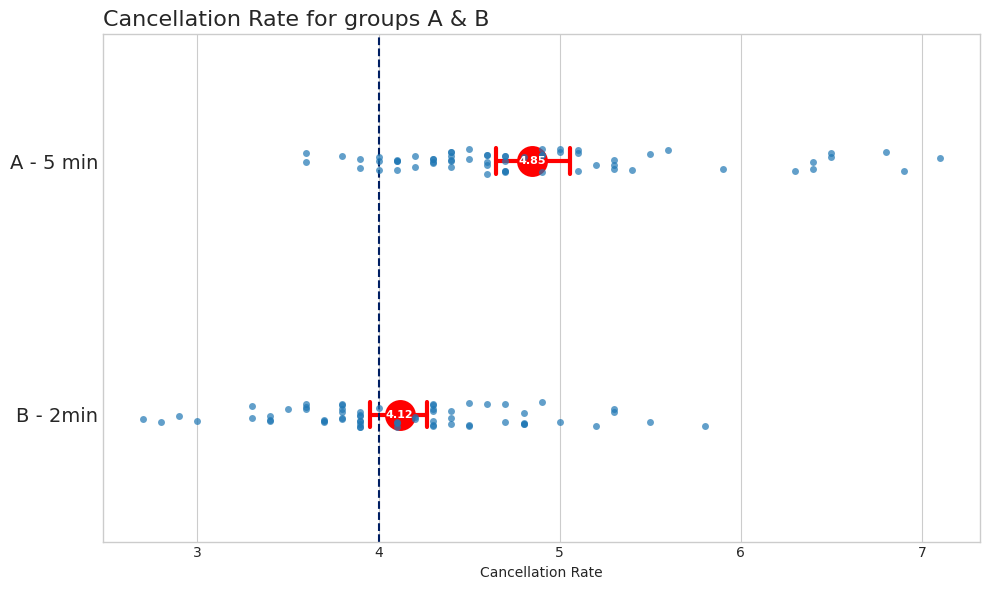

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.stripplot(
    data=uber, x='cancellation_rate', y='group',
    ax=ax, alpha=0.7, jitter=0.05
)

sns.pointplot(
    data=uber, x='cancellation_rate', y='group',
    ax=ax, join=False, errorbar=('ci', 95),
    color='red', markersize=20, linewidth=3, capsize=0.1
)

# Mean labels
group_means = uber.groupby('group')['cancellation_rate'].mean()
for i, group in enumerate(group_means.index):
    mean_val = group_means[group]
    ax.text(mean_val, i, f'{mean_val:.2f}',
            color='white', fontsize=8, fontweight='bold',
            ha='center', va='center')

ax.axvline(x=4, color="#001e62", linestyle="--", label="4% target")
ax.set_title("Cancellation Rate for groups A & B", loc='left', fontsize=16)
ax.set(xlabel="Cancellation Rate", ylabel=None)
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

## 4. Match Rate by Group (with 95% CI)

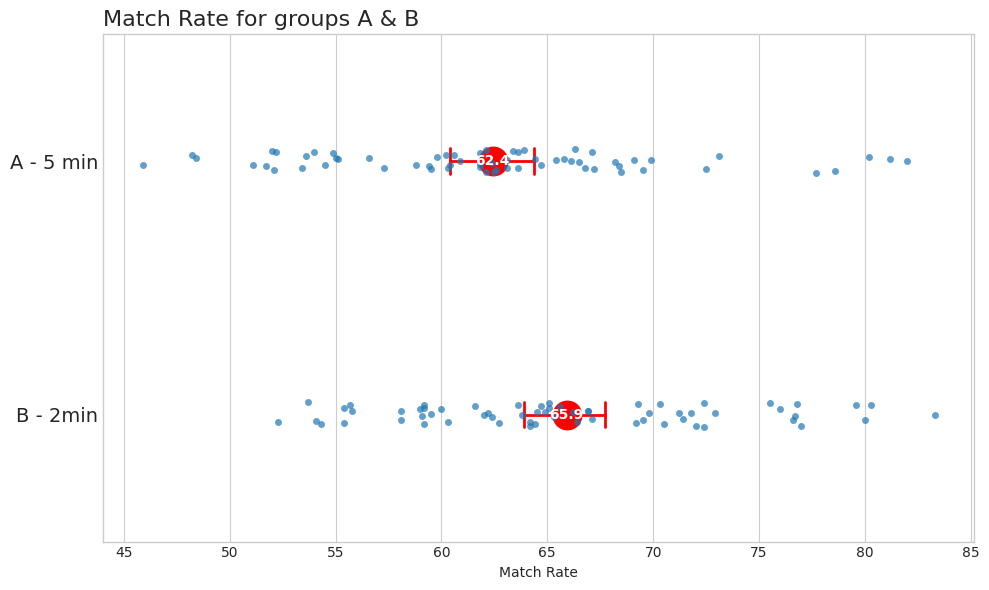

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.stripplot(
    data=uber, x='match_rate', y='group',
    ax=ax, alpha=0.7, jitter=0.05
)

sns.pointplot(
    data=uber, x='match_rate', y='group',
    ax=ax, join=False, errorbar=('ci', 95),
    color='red', markersize=20, linewidth=2, capsize=0.1
)

# Mean labels
group_means_match = uber.groupby('group')['match_rate'].mean()
for i, group in enumerate(group_means_match.index):
    mean_val = group_means_match[group]
    ax.text(mean_val, i, f'{mean_val:.1f}',
            color='white', fontsize=10, fontweight='bold',
            ha='center', va='center')

ax.set_title("Match Rate for groups A & B", loc='left', fontsize=16)
ax.set(xlabel="Match Rate", ylabel=None)
ax.tick_params(axis='y', labelsize=14)

plt.tight_layout()
plt.show()

## 5. Summary Statistics

In [13]:
print("--- Cancellation Rate by Group ---")
display(
    uber.groupby('group')['cancellation_rate']
    .describe().round(2).reset_index()
)

print("--- Match Rate by Group ---")
display(
    uber.groupby('group')['match_rate']
    .describe().round(2).reset_index()
)

--- Cancellation Rate by Group ---


,group,count,mean,std,min,25%,50%,75%,max
0,A - 5 min,63.0,4.85,0.83,3.6,4.30,4.7,5.15,7.1
1,B - 2min,63.0,4.12,0.65,2.7,3.75,4.1,4.50,5.8


--- Match Rate by Group ---


,group,count,mean,std,min,25%,50%,75%,max
0,A - 5 min,63.0,62.43,8.01,45.9,56.95,62.4,66.65,82.0
1,B - 2min,63.0,65.92,7.52,52.3,59.75,65.1,71.30,83.3


## 6. Hypothesis Testing

### One-sample t-tests: Is each group's cancellation rate = 4%?
### Two-sample t-tests: Do the groups differ from each other?

In [17]:

def one_sample_ttest_summary(data, col, popmean, group_name):
    x = data[col].dropna()
    t, p = stats.ttest_1samp(x, popmean)
    ci = stats.t.interval(0.95, df=len(x)-1, loc=x.mean(), scale=stats.sem(x))
    print(f"--- One-Sample T-Test: {group_name} | {col} vs μ = {popmean} ---")
    print(f"  n         : {len(x)}")
    print(f"  mean      : {x.mean():.4f}")
    print(f"  std       : {x.std(ddof=1):.4f}")
    print(f"  95% CI    : [{ci[0]:.4f}, {ci[1]:.4f}]")
    print(f"  t         : {t:.4f}")
    print(f"  df        : {len(x)-1}")
    print(f"  p-value   : {p:.4f}  {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'}\n")

def two_sample_ttest_summary(a, b, col, label_a, label_b):
    x, y = a[col].dropna(), b[col].dropna()
    t, p = stats.ttest_ind(x, y, equal_var=False)
    df = (x.var()/len(x) + y.var()/len(y))**2 / (
          (x.var()/len(x))**2/(len(x)-1) + (y.var()/len(y))**2/(len(y)-1))
    diff = x.mean() - y.mean()
    ci = stats.t.interval(0.95, df=df, loc=diff,
                          scale=np.sqrt(x.var()/len(x) + y.var()/len(y)))
    print(f"--- Two-Sample Welch T-Test: {col} | {label_a} vs {label_b} ---")
    print(f"  n         : {len(x)}  vs  {len(y)}")
    print(f"  mean      : {x.mean():.4f}  vs  {y.mean():.4f}")
    print(f"  std       : {x.std(ddof=1):.4f}  vs  {y.std(ddof=1):.4f}")
    print(f"  diff      : {diff:.4f}")
    print(f"  95% CI    : [{ci[0]:.4f}, {ci[1]:.4f}]")
    print(f"  t         : {t:.4f}")
    print(f"  df        : {df:.2f}")
    print(f"  p-value   : {p:.4f}  {'***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'}\n")

# --- Run tests ---
one_sample_ttest_summary(group_a, 'cancellation_rate', popmean=4, group_name='Group A')
one_sample_ttest_summary(group_b, 'cancellation_rate', popmean=4, group_name='Group B')
two_sample_ttest_summary(group_a, group_b, 'cancellation_rate', 'Group A', 'Group B')
two_sample_ttest_summary(group_a, group_b, 'match_rate',         'Group A', 'Group B')

--- One-Sample T-Test: Group A | cancellation_rate vs μ = 4 ---
  n         : 63
  mean      : 4.8492
  std       : 0.8347
  95% CI    : [4.6390, 5.0594]
  t         : 8.0751
  df        : 62
  p-value   : 0.0000  ***

--- One-Sample T-Test: Group B | cancellation_rate vs μ = 4 ---
  n         : 63
  mean      : 4.1159
  std       : 0.6459
  95% CI    : [3.9532, 4.2785]
  t         : 1.4240
  df        : 62
  p-value   : 0.1595  ns

--- Two-Sample Welch T-Test: cancellation_rate | Group A vs Group B ---
  n         : 63  vs  63
  mean      : 4.8492  vs  4.1159
  std       : 0.8347  vs  0.6459
  diff      : 0.7333
  95% CI    : [0.4700, 0.9967]
  t         : 5.5150
  df        : 116.65
  p-value   : 0.0000  ***

--- Two-Sample Welch T-Test: match_rate | Group A vs Group B ---
  n         : 63  vs  63
  mean      : 62.4270  vs  65.9159
  std       : 8.0079  vs  7.5219
  diff      : -3.4889
  95% CI    : [-6.2287, -0.7491]
  t         : -2.5205
  df        : 123.52
  p-value   : 0.0130  *